# Idea

Get more insight into the correlations between X, and y

## Naming Conventions with example:

Belong to X:
- Feature: *|avg B|* (refers to a measured physical parameter)
- Lag: *|avg B|_lag_1* (refers to all columns in X)

Belong to y:
- Target: *y_step_1*

Belong to the Model:
- Coefficient: each coefficient belongs to one Lag and a target

In [1]:
import os
# os.nice(19)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score
from pathlib import Path
from utils.data_loader import find_repo_root
from utils.modeling import aggregate_multistep_predictions
import joblib
import re

# Settings

In [2]:
sampling_rate = '5min'  # available: '20s', '1min', '5min'
columns =['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
target = 'trend'
m = 15

# Load Data

In [3]:
DATA_DIR = find_repo_root() / Path("Dataset/modeling/")
DATA_file = DATA_DIR / Path(f"GFOC_modeling_{sampling_rate}.parquet")
GFOC_data = pd.read_parquet(DATA_file, columns=columns)
# filter by time range
print(f"✅ Successfully loaded data with shape: {GFOC_data.shape}")
# column names
print("Column names in the dataset:")
print(GFOC_data.columns.tolist())
print("Sample rate:", pd.infer_freq(GFOC_data.index))

X_file = DATA_DIR / Path(f"X_{sampling_rate}.parquet")
X = pd.read_parquet(X_file)
y_file = DATA_DIR / Path(f"y_{target}_{sampling_rate}.parquet")
y = pd.read_parquet(y_file)

print(f"✅ Successfully loaded features X with shape: {X.shape} and target y with shape: {y.shape}")

✅ Successfully loaded data with shape: (210528, 4)
Column names in the dataset:
['orbital_decay', 'trend', '|avg B|', 'F10.7 (LASP)']
Sample rate: 5min
✅ Successfully loaded features X with shape: (209790, 538) and target y with shape: (209790, 48)


# 1. Check Correlation between X and y

In [10]:
print(X.columns.tolist())

['|avg B|_lag_1', '|avg B|_lag_2', '|avg B|_lag_3', '|avg B|_lag_4', '|avg B|_lag_5', '|avg B|_lag_6', '|avg B|_lag_7', '|avg B|_lag_8', '|avg B|_lag_9', '|avg B|_lag_10', '|avg B|_lag_11', '|avg B|_lag_12', '|avg B|_lag_13', '|avg B|_lag_14', '|avg B|_lag_15', '|avg B|_lag_16', '|avg B|_lag_17', '|avg B|_lag_18', '|avg B|_lag_19', '|avg B|_lag_20', '|avg B|_lag_21', '|avg B|_lag_22', '|avg B|_lag_23', '|avg B|_lag_24', '|avg B|_lag_25', '|avg B|_lag_26', '|avg B|_lag_27', '|avg B|_lag_28', '|avg B|_lag_29', '|avg B|_lag_30', '|avg B|_lag_31', '|avg B|_lag_32', '|avg B|_lag_33', '|avg B|_lag_34', '|avg B|_lag_35', '|avg B|_lag_36', '|avg B|_lag_42', '|avg B|_lag_48', '|avg B|_lag_54', '|avg B|_lag_60', '|avg B|_lag_66', '|avg B|_lag_72', '|avg B|_lag_78', '|avg B|_lag_84', '|avg B|_lag_90', '|avg B|_lag_96', '|avg B|_lag_102', '|avg B|_lag_108', '|avg B|_lag_114', '|avg B|_lag_120', '|avg B|_lag_126', '|avg B|_lag_132', '|avg B|_lag_138', '|avg B|_lag_144', '|avg B|_lag_150', '|avg B|_

## 1.1 Correlation Matrix for X

In [4]:
corr_X = X.corr()


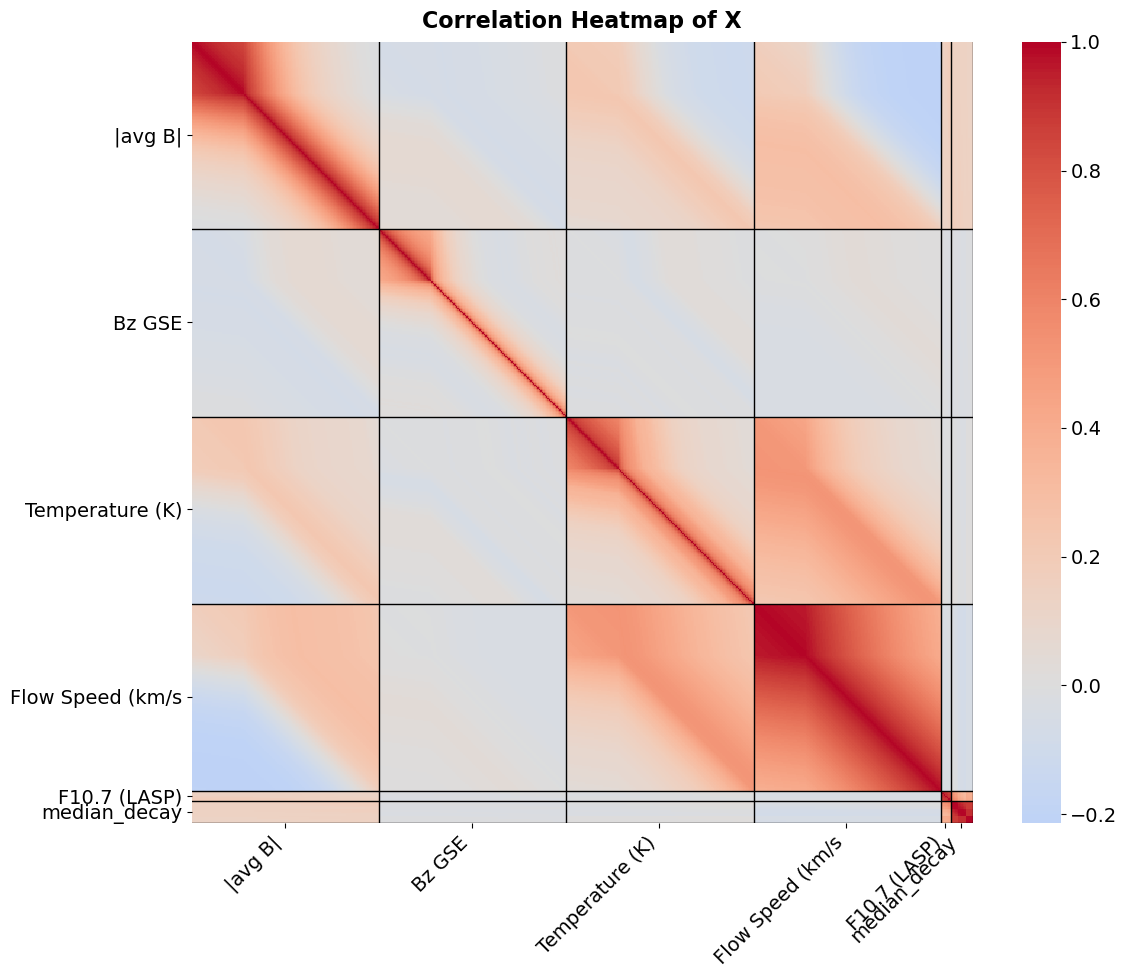

In [30]:
# Define groups
groups = [
    "|avg B|",
    "Bz GSE",
    "Temperature (K)",
    "Flow Speed (km/s",
    "F10.7 (LASP)",
    "median_decay"
]

# Find column indices belonging to each group
group_indices = {}
for g in groups:
    group_indices[g] = [i for i, c in enumerate(X.columns) if c.startswith(g)]

# Compute boundaries and centers
boundaries = []
centers = []
labels = []

for g, idx in group_indices.items():
    if len(idx) == 0:
        continue
    start = min(idx)
    end = max(idx)
    boundaries.append(end + 1)
    centers.append((start + end) / 2)
    labels.append(g)
# Plot heatmap
plt.rcParams.update({'font.size': 14})
plt.figure(figsize=(12,10))
ax = sns.heatmap(corr_X, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)

# Draw group separators
for b in boundaries:
    ax.axhline(b, color="black", lw=1)
    ax.axvline(b, color="black", lw=1)

# Set group labels
ax.set_xticks(centers)
ax.set_yticks(centers)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels)

plt.title("Correlation Heatmap of X")
plt.tight_layout()
plt.show()

## 1.2 Correlation of y

In [16]:
print(y.columns.tolist())

['y_step_1', 'y_step_2', 'y_step_3', 'y_step_4', 'y_step_5', 'y_step_6', 'y_step_7', 'y_step_8', 'y_step_9', 'y_step_10', 'y_step_11', 'y_step_12', 'y_step_13', 'y_step_14', 'y_step_15', 'y_step_16', 'y_step_17', 'y_step_18', 'y_step_19', 'y_step_20', 'y_step_21', 'y_step_22', 'y_step_23', 'y_step_24', 'y_step_25', 'y_step_26', 'y_step_27', 'y_step_28', 'y_step_29', 'y_step_30', 'y_step_31', 'y_step_32', 'y_step_33', 'y_step_34', 'y_step_35', 'y_step_36', 'y_step_37', 'y_step_38', 'y_step_39', 'y_step_40', 'y_step_41', 'y_step_42', 'y_step_43', 'y_step_44', 'y_step_45', 'y_step_46', 'y_step_47', 'y_step_48']


In [17]:
corr_y = y.corr()

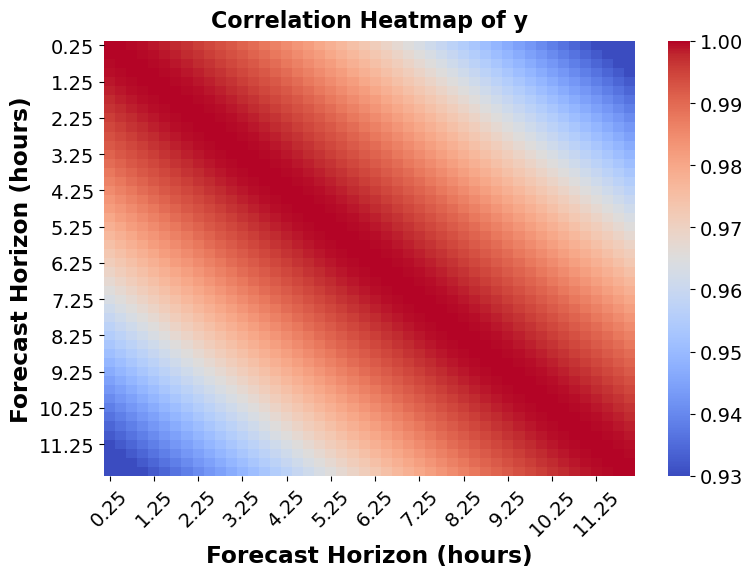

In [29]:
n = corr_y.shape[0]

# Convert step index to hours
hours = np.arange(1, n + 1) / 4

# Show tick every hour (4 steps)
tick_positions = np.arange(0, n, 4)
tick_labels = hours[tick_positions]

plt.figure(figsize=(8,6))

ax = sns.heatmap(
    corr_y,
    cmap="coolwarm",
    vmin=0.93,
    vmax=1.0,
    xticklabels=False,
    yticklabels=False
)

ax.set_xticks(tick_positions + 0.5)
ax.set_yticks(tick_positions + 0.5)

ax.set_xticklabels(tick_labels, rotation=45)
ax.set_yticklabels(tick_labels)

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Forecast Horizon (hours)")
plt.title("Correlation Heatmap of y")
plt.tight_layout()

plt.show()

## 1.3 Correlation of X with y

In [33]:
corr_xy = pd.concat([X, y], axis=1).corr().loc[X.columns, y.columns]

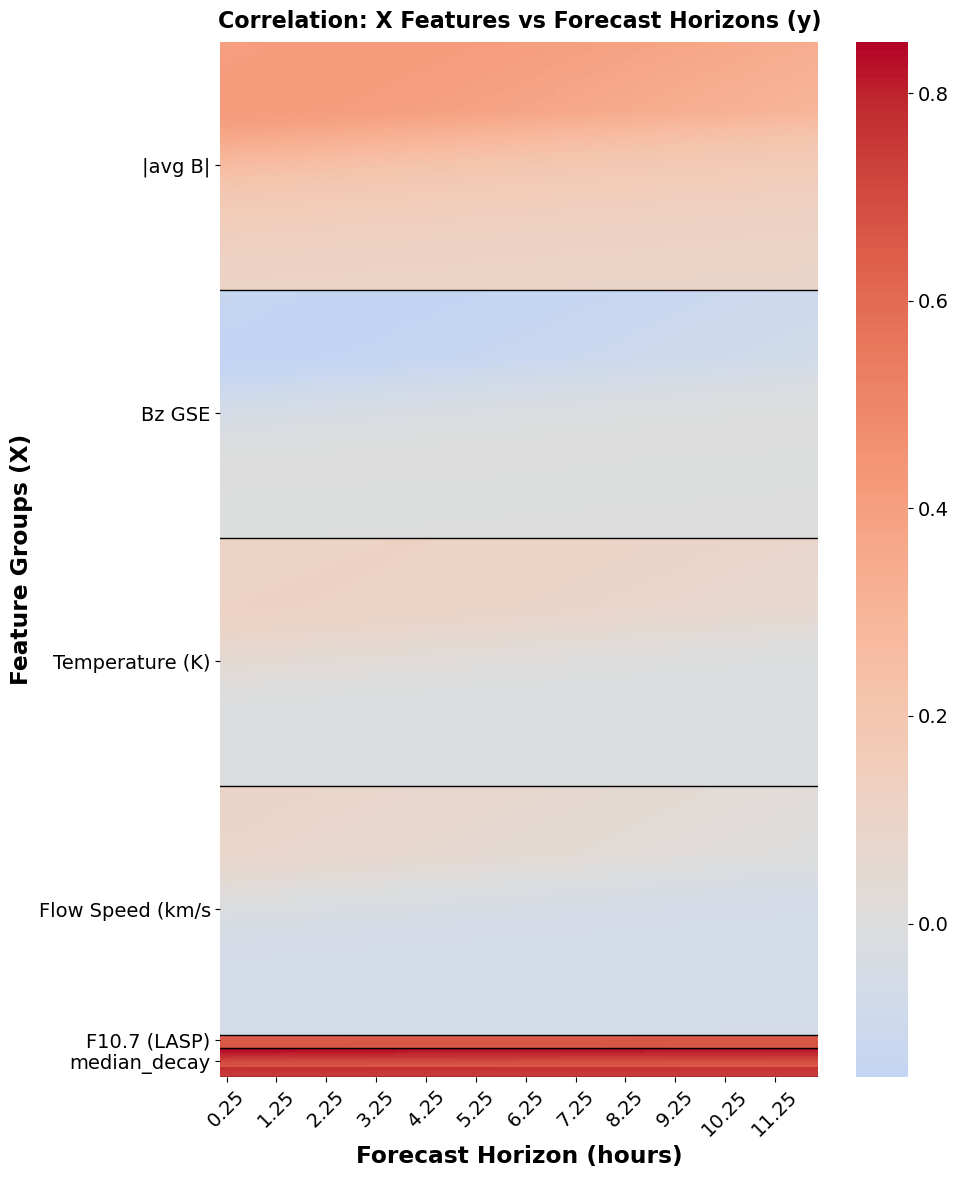

In [23]:
# ---- X GROUPS ----
groups = [
    "|avg B|",
    "Bz GSE",
    "Temperature (K)",
    "Flow Speed (km/s",
    "F10.7 (LASP)",
    "median_decay"
]

group_indices = {}
for g in groups:
    group_indices[g] = [i for i, c in enumerate(X.columns) if c.startswith(g)]

boundaries = []
centers = []
labels = []

for g, idx in group_indices.items():
    if len(idx) == 0:
        continue
    start = min(idx)
    end = max(idx)
    boundaries.append(end + 1)
    centers.append((start + end) / 2)
    labels.append(g)

# ---- Y HORIZONS ----
n_y = len(y.columns)
hours = np.arange(1, n_y + 1) / 4

tick_positions_y = np.arange(0, n_y, 4)
tick_labels_y = hours[tick_positions_y]

# ---- PLOT ----
plt.figure(figsize=(10,12))

ax = sns.heatmap(
    corr_xy,
    cmap="coolwarm",
    center=0,
    xticklabels=False,
    yticklabels=False
)

# X group separators
for b in boundaries:
    ax.axhline(b, color="black", lw=1)

# X group labels
ax.set_yticks(centers)
ax.set_yticklabels(labels)

# Y horizon labels
ax.set_xticks(tick_positions_y + 0.5)
ax.set_xticklabels(tick_labels_y, rotation=45)

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Feature Groups (X)")
plt.title("Correlation: X Features vs Forecast Horizons (y)")
plt.tight_layout()

plt.show()

### Mean correlation of feature groups vs forecast horizon

Group: |avg B|, Mean Correlation: 0.2378
Group: |avg B|, Max Correlation: 0.2721 at hour 0.25
Group: |avg B|, Min Correlation: 0.1971 at hour 12.00
Group: Bz GSE, Mean Correlation: -0.0507
Group: Bz GSE, Max Correlation: -0.0291 at hour 12.00
Group: Bz GSE, Min Correlation: -0.0672 at hour 0.25
Group: Temperature (K), Mean Correlation: 0.0382
Group: Temperature (K), Max Correlation: 0.0510 at hour 0.25
Group: Temperature (K), Min Correlation: 0.0218 at hour 12.00
Group: Flow Speed (km/s, Mean Correlation: -0.0141
Group: Flow Speed (km/s, Max Correlation: 0.0075 at hour 0.25
Group: Flow Speed (km/s, Min Correlation: -0.0347 at hour 12.00
Group: F10.7 (LASP), Mean Correlation: 0.6592
Group: F10.7 (LASP), Max Correlation: 0.6615 at hour 12.00
Group: F10.7 (LASP), Min Correlation: 0.6566 at hour 0.25
Group: median_decay, Mean Correlation: 0.7499
Group: median_decay, Max Correlation: 0.7568 at hour 0.25
Group: median_decay, Min Correlation: 0.7431 at hour 12.00


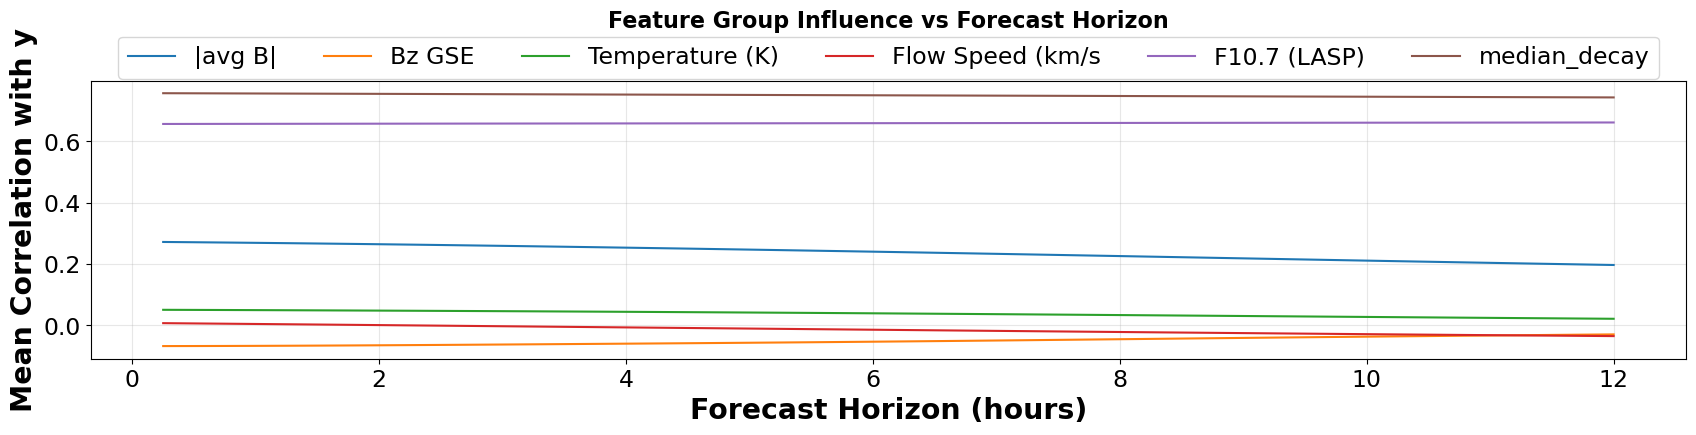

In [46]:
groups = [
    "|avg B|",
    "Bz GSE",
    "Temperature (K)",
    "Flow Speed (km/s",
    "F10.7 (LASP)",
    "median_decay"
]

# Forecast horizon in hours
n_y = len(y.columns)
hours = np.arange(1, n_y + 1) / 4
plt.rcParams.update({'font.size': 17})
plt.figure(figsize=(18,6))

for g in groups:
    
    cols = [c for c in X.columns if c.startswith(g)]
    
    if len(cols) == 0:
        continue
    
    # mean correlation across all lags in group
    mean_corr = corr_xy.loc[cols].mean(axis=0)
    
    plt.plot(hours, mean_corr, label=g)
    print(f"Group: {g}, Mean Correlation: {mean_corr.mean():.4f}")
    print(f"Group: {g}, Max Correlation: {mean_corr.max():.4f} at hour {hours[mean_corr.argmax()]:.2f}")
    print(f"Group: {g}, Min Correlation: {mean_corr.min():.4f} at hour {hours[mean_corr.argmin()]:.2f}")

plt.xlabel("Forecast Horizon (hours)")
plt.ylabel("Mean Correlation with y")
plt.title("Feature Group Influence vs Forecast Horizon")
ax = plt.gca()

# keep legend above axes
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.2), ncol=6)
ax.grid(alpha=0.3)

# keep title above legend
ax.set_title(ax.get_title(), y=1.14)

# reserve top space for title + legend
plt.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()

### ag (x-axis) vs Forecast Horizon (y-axis) heatmap for each feature group.

In [25]:
corr_all = pd.concat([X, y], axis=1).corr()

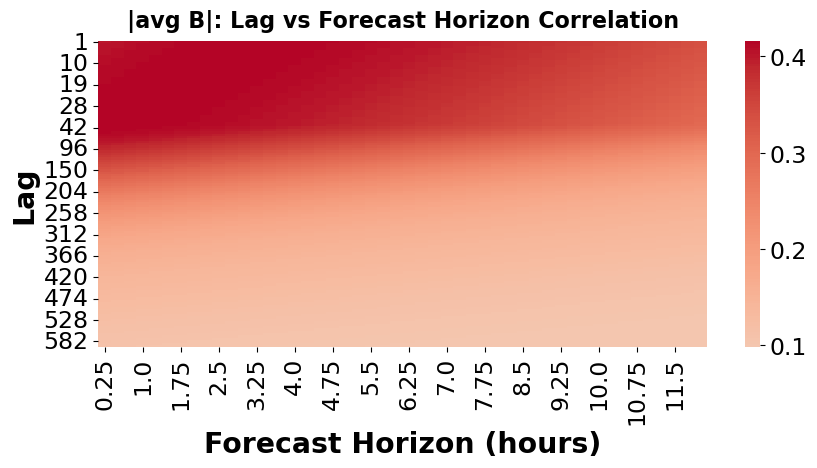

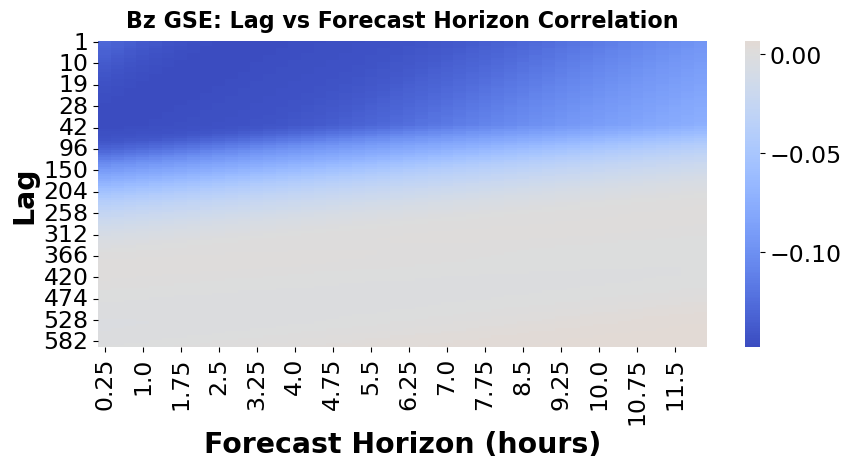

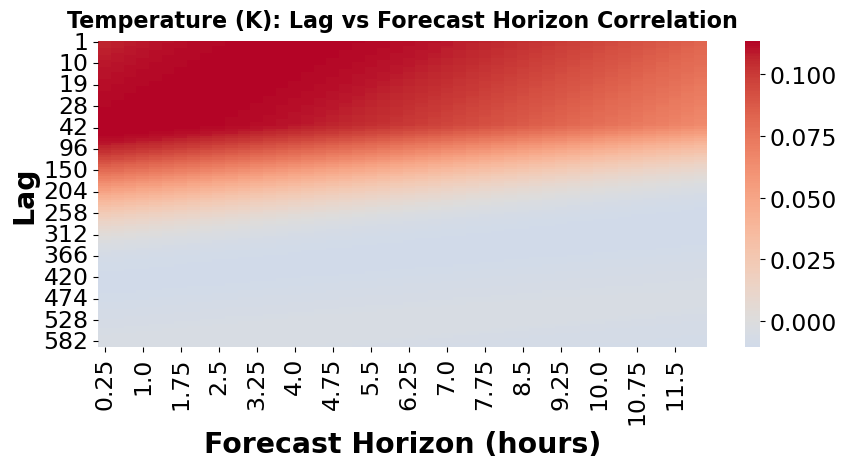

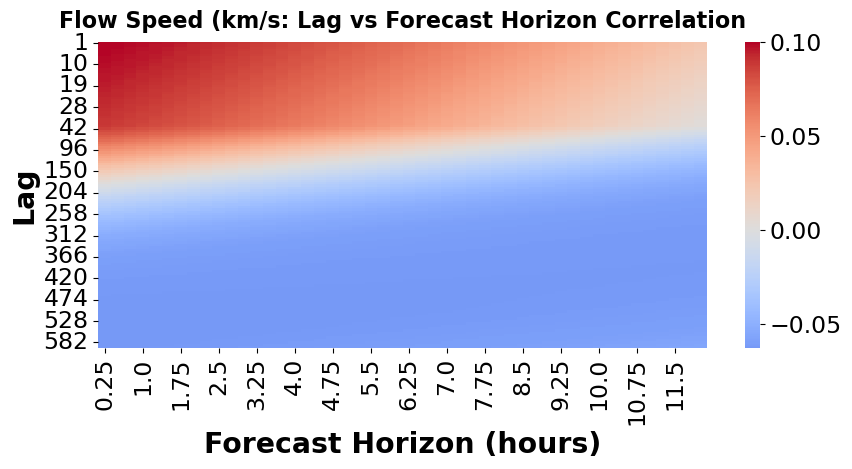

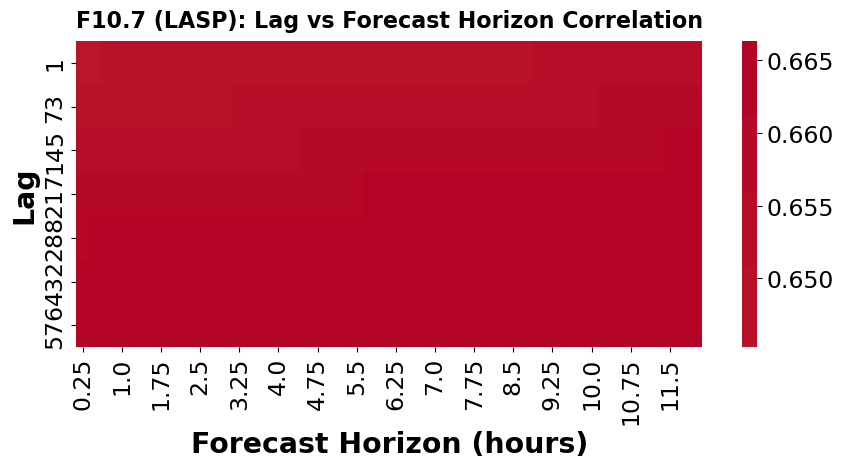

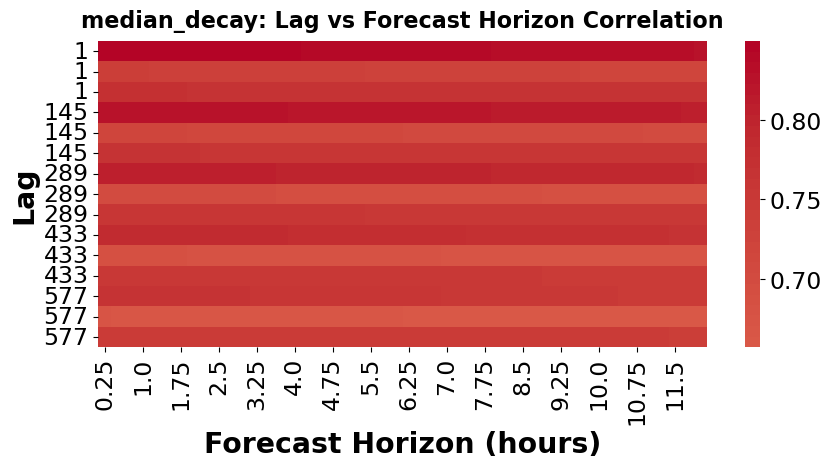

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

groups = [
    "|avg B|",
    "Bz GSE",
    "Temperature (K)",
    "Flow Speed (km/s",
    "F10.7 (LASP)",
    "median_decay"
]

for feature in groups:

    cols = [c for c in X.columns if c.startswith(feature)]
    if not cols:
        continue

    # extract lag numbers
    lags = [int(c.split("_lag_")[1]) for c in cols]

    # correlation with y
    corr_xy_2 = corr_all.loc[cols, y.columns]

    lag_horizon = corr_xy_2.copy()
    lag_horizon.index = lags
    lag_horizon.columns = np.arange(1, len(y.columns)+1) / 4
    lag_horizon = lag_horizon.sort_index()

    # determine color scale dynamically
    vmin = lag_horizon.values.min()
    vmax = lag_horizon.values.max()

    plt.figure(figsize=(9,5))

    sns.heatmap(
        lag_horizon,
        cmap="coolwarm",
        center=0,
        vmin=vmin,
        vmax=vmax
    )

    plt.title(f"{feature}: Lag vs Forecast Horizon Correlation")
    plt.xlabel("Forecast Horizon (hours)")
    plt.ylabel("Lag")

    plt.tight_layout()
    plt.show()